Assessment columns:
['assessment_id', 'month', 'course_id', 'batch', 'score', 'attendance_pct']

Course columns:
['course_id', 'course', 'department']

Duplicate rows removed: 1
Assessment rows after cleaning: 12

Merged rows: 12
Missing department values: 0

================ DEPARTMENT SUMMARY ================
   department  total_assessments  total_pass  pass_rate
0    Business                  6           5      83.33
1  Technology                  6           3      50.00

================ PASS RATE DETAILS ================
Business: 5 / 6 = 83.33%
Technology: 3 / 6 = 50.0%

================ MONTHLY AVERAGE SCORE ================
month
Jan    55.00
Feb    62.75
Mar    66.75
Name: score, dtype: float64


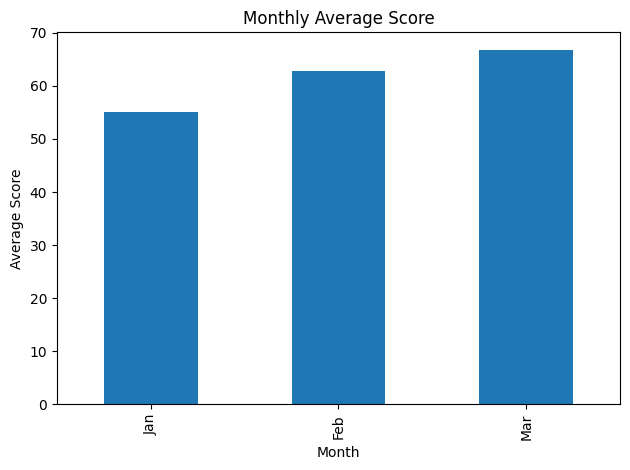


PRACTICAL COMPLETED SUCCESSFULLY
Clean data rows: 12
Courses rows: 4
Missing departments: 0

Files created:
1. output/clean_data.csv
2. output/python_summary.csv
3. output/python_chart.png


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================
# 1. LOAD CSV FILES
# =====================================================

assessments = pd.read_csv("../Excel/assessments.csv")
courses = pd.read_csv("../Excel/courses.csv")

# Remove extra spaces from column names
assessments.columns = assessments.columns.str.strip().str.lower()
courses.columns = courses.columns.str.strip().str.lower()

print("Assessment columns:")
print(assessments.columns.tolist())

print("\nCourse columns:")
print(courses.columns.tolist())


# =====================================================
# 2. CONVERT NUMERIC COLUMNS
# =====================================================

# Find score column safely
score_col = [col for col in assessments.columns if col.strip().lower() == "score"][0]

# Find attendance column safely
attendance_col = [
    col for col in assessments.columns
    if col.strip().lower() == "attendance_pct"
][0]

assessments[score_col] = pd.to_numeric(
    assessments[score_col],
    errors="coerce"
)

assessments[attendance_col] = pd.to_numeric(
    assessments[attendance_col],
    errors="coerce"
)


# =====================================================
# 3. REMOVE DUPLICATE
# =====================================================

before = len(assessments)

assessments = assessments.drop_duplicates()

after = len(assessments)

print("\nDuplicate rows removed:", before - after)
print("Assessment rows after cleaning:", after)


# =====================================================
# 4. MERGE WITH COURSES
# =====================================================

merged_df = assessments.merge(
    courses,
    on="course_id",
    how="left",
    suffixes=("", "_lookup")
)


# =====================================================
# 5. FIX DEPARTMENT AFTER MERGE
# =====================================================

if "department_lookup" in merged_df.columns:
    merged_df["department"] = merged_df["department_lookup"]
    merged_df.drop(columns=["department_lookup"], inplace=True)

print("\nMerged rows:", len(merged_df))

print(
    "Missing department values:",
    merged_df["department"].isna().sum()
)


# =====================================================
# 6. CREATE PASS FLAG
# =====================================================

merged_df["pass_flag"] = (
    merged_df["score"] >= 50
).astype(int)


# =====================================================
# 7. DEPARTMENT SUMMARY
# =====================================================

summary = merged_df.groupby("department").agg(
    total_assessments=("assessment_id", "count"),
    total_pass=("pass_flag", "sum")
).reset_index()

summary["pass_rate"] = (
    summary["total_pass"]
    / summary["total_assessments"]
    * 100
).round(2)


print("\n================ DEPARTMENT SUMMARY ================")
print(summary)


# =====================================================
# 8. PRINT PASSING COUNT / TOTAL EXPLICITLY
# =====================================================

print("\n================ PASS RATE DETAILS ================")

for _, row in summary.iterrows():
    print(
        f"{row['department']}: "
        f"{row['total_pass']} / "
        f"{row['total_assessments']} "
        f"= {row['pass_rate']}%"
    )


# =====================================================
# 9. MONTHLY AVERAGE SCORE
# =====================================================

month_order = ["Jan", "Feb", "Mar"]

monthly_avg = (
    merged_df.groupby("month")["score"]
    .mean()
    .reindex(month_order)
)

print("\n================ MONTHLY AVERAGE SCORE ================")
print(monthly_avg)


# =====================================================
# 10. CREATE OUTPUT FOLDER
# =====================================================

os.makedirs("output", exist_ok=True)


# =====================================================
# 11. CREATE CHART
# =====================================================

monthly_avg.plot(kind="bar")

plt.title("Monthly Average Score")
plt.xlabel("Month")
plt.ylabel("Average Score")

plt.tight_layout()

plt.savefig(
    "output/python_chart.png",
    dpi=300
)

plt.show()


# =====================================================
# 12. EXPORT CLEAN DATA
# =====================================================

merged_df.to_csv(
    "output/clean_data.csv",
    index=False
)


# =====================================================
# 13. EXPORT SUMMARY
# =====================================================

summary.to_csv(
    "output/python_summary.csv",
    index=False
)


# =====================================================
# 14. FINAL CHECK
# =====================================================

print("\n====================================================")
print("PRACTICAL COMPLETED SUCCESSFULLY")
print("====================================================")

print("Clean data rows:", len(merged_df))
print("Courses rows:", len(courses))
print("Missing departments:", merged_df["department"].isna().sum())

print("\nFiles created:")
print("1. output/clean_data.csv")
print("2. output/python_summary.csv")
print("3. output/python_chart.png")